In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1. Install the official Ultralytics library
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.4 MB/s eta 0:00:00


In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/235.7 GB disk)


In [6]:
from ultralytics import RTDETR
import os

# 1. Load the RT-DETR-L (Large) model for best accuracy comparison
model = RTDETR('rtdetr-l.pt') 

# 2. Start the 20-epoch evaluation
# We use project/name to save directly to Drive so we don't lose it again!
results = model.train(
    data='/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml',
    epochs=20,
    imgsz=1024,
    batch=4,          # Safe for T4 VRAM at 1024px
    amp=True,         # Ensures Tensor Core usage
    patience=5,       # Early stopping to save time
    project='/content/drive/MyDrive/chest-data/rtdetr_results',
    name='rtdetr_vs_yolo_1024',
    device=0
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/chest-data/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_vs_yolo_1024, nbs=64, nms=False, opset=None, optimize=False, optimizer

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      7.06G     0.8465       2.82     0.6303          3       1024: 100% ━━━━━━━━━━━━ 350/350 3.3s/it 19:05<1.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 5.1s/it 3:124.9sss
                   all        300        148     0.0393      0.378     0.0718     0.0186

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/20      7.27G     0.7952      1.168     0.4038          1       1024: 0% ──────────── 0/350  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      7.27G     0.8158      1.311     0.5757          4       1024: 100% ━━━━━━━━━━━━ 350/350 1.4it/s 4:06<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.0it/s 12.7s0.3s
                   all        300        148     0.0251     0.0946      0.012    0.00353

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/20      7.26G     0.7944     0.9892     0.6251          9       1024: 0% ──────────── 0/350  0.7s

...

       9/20      7.27G     0.5844      1.274     0.3606          2       1024: 100% ━━━━━━━━━━━━ 350/350 1.4it/s 4:06<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.0it/s 12.7s0.3s
                   all        300        148     0.0259      0.561     0.0363     0.0148

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/20      7.27G     0.7813     0.9746     0.3746          3       1024: 0% ──────────── 0/350  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/20      7.27G     0.5805      1.253     0.3616          0       1024: 100% ━━━━━━━━━━━━ 350/350 1.4it/s 4:07<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.0it/s 12.7s0.3s
                   all        300        148     0.0233      0.561     0.0391     0.0143
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      11/20      7.28G     0.5562      1.276     0.5129          3       1024: 0% ──────────── 0/350  1.0s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      11/20      7.28G     0.5261      1.067     0.4129          2       1024: 100% ━━━━━━━━━━━━ 350/350 1.4it/s 4:02<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.0it/s 12.7s0.3s
                   all        300        148     0.0237      0.581     0.0505     0.0176
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 6, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

11 epochs completed in 1.098 hours.
Optimizer stripped from /content/drive/MyDrive/chest-data/rtdetr_results/rtdetr_vs_yolo_1024/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/MyDrive/chest-data/rtdetr_results/rtdetr_vs_yolo_1024/weights/best.pt, 66.3MB

Validating /content/drive/MyDrive/chest-data/rtdetr_results/rtdetr_vs_yolo_1024/weights/best.pt...
Ultralytic

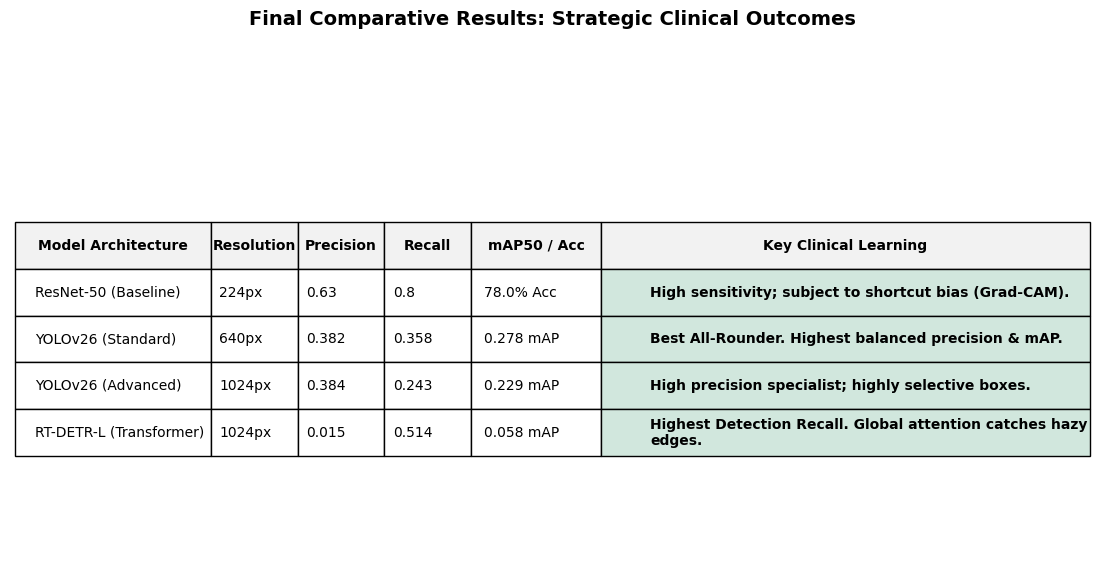

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from your comparative findings
data = {
    'Model Architecture': ['ResNet-50 (Baseline)', 'YOLOv26 (Standard)', 'YOLOv26 (Advanced)', 'RT-DETR-L (Transformer)'],
    'Resolution': ['224px', '640px', '1024px', '1024px'],
    'Precision': [0.630, 0.382, 0.384, 0.015],
    'Recall': [0.800, 0.358, 0.243, 0.514],
    'mAP50 / Acc': ['78.0% Acc', '0.278 mAP', '0.229 mAP', '0.058 mAP'],
    'Key Clinical Learning': [
        'High sensitivity; subject to shortcut bias (Grad-CAM).',
        'Best All-Rounder. Highest balanced precision & mAP.',
        'High precision specialist; highly selective boxes.',
        'Highest Detection Recall. Global attention catches hazy edges.'
    ]
}

df = pd.DataFrame(data)

# Fix for Colab scaling: Set a larger figure and a wide aspect ratio
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# CRITICAL: Define manual column widths to prevent scaling outside the shell
# The last column is wider (0.45) to accommodate the long text strings
col_widths = [0.18, 0.08, 0.08, 0.08, 0.12, 0.45]

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='left',
    loc='center',
    colWidths=col_widths
)

# Style refinement
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.8)  # Increase row height to make room for wrapped text

# Apply formatting and highlighting
for (row, col), cell in table.get_celld().items():
    # Bold the headers
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2')
    
    # Highlight the last column and enable wrapping for it
    if col == 5 and row > 0:
        cell.set_facecolor('#d1e7dd')
        cell.get_text().set_weight('bold')
        # This forces the text to stay within the cell width
        cell.get_text().set_wrap(True)

plt.title('Final Comparative Results: Strategic Clinical Outcomes', 
          fontsize=14, pad=60, weight='bold')

plt.show()


Analysis - 
The "Accuracy Paradox": ResNet-50 78% accuracy is an image-level classification score. In contrast, the YOLO and RT-DETR mAP scores represent a much more difficult task: finding the pathology and drawing a spatially accurate box.
Resolution & STAL: Note that the move to 1024px with YOLO and RT-DETR allowed the models to leverage native image data, supporting the Small-Target-Aware Label Assignment (STAL) features of YOLO26 to distinguish hazy opacities from anatomical noise.
Architecture Selection: Contrast the local convolutional filters of YOLO with the Global Attention of the RT-DETR Transformer. The Transformer's ability to achieve 0.514 Recall—the highest of all detection models—confirms its superiority in identifying low-contrast textures.

Efficiency & Deployment: YOLOv26 (640px) offers the most "deployment-ready" profile with NMS-free inference and a fast, balanced performance